<a href="https://colab.research.google.com/github/hashim0011222/ITA-0614/blob/main/Experiment_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Q1 - FIND-S Algorithm

import pandas as pd

# Training dataset
data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Weak'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

print("Training Data:")
print(df)

# FIND-S
hypothesis = None

for index, row in df.iterrows():

    if row['EnjoySport'] == 'Yes':

        attributes = row.drop('EnjoySport').values

        if hypothesis is None:
            hypothesis = list(attributes)

        else:
            for i in range(len(hypothesis)):
                if hypothesis[i] != attributes[i]:
                    hypothesis[i] = '?'

print("\nMost Specific Hypothesis:")
print(hypothesis)

Training Data:
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High    Weak  Cool   Change        Yes

Most Specific Hypothesis:
['Sunny', 'Warm', '?', '?', '?', '?']


In [3]:
# Q2 - Candidate Elimination Algorithm

import pandas as pd

data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Weak'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

attributes = list(df.columns[:-1])

# Initial boundaries
S = ['Ø'] * len(attributes)
G = [['?'] * len(attributes)]

print("Training Data:")
print(df)

for _, example in df.iterrows():

    x = list(example[attributes])
    target = example['EnjoySport']

    if target == 'Yes':

        # Remove inconsistent general hypotheses
        new_G = []

        for g in G:
            consistent = True

            for i in range(len(attributes)):
                if g[i] != '?' and g[i] != x[i]:
                    consistent = False

            if consistent:
                new_G.append(g)

        G = new_G

        # Generalize S
        if S[0] == 'Ø':
            S = x.copy()
        else:
            for i in range(len(S)):
                if S[i] != x[i]:
                    S[i] = '?'

    else:

        # Specialize G
        new_G = []

        for g in G:

            for i in range(len(attributes)):

                if g[i] == '?':
                    if S[i] != '?' and S[i] != 'Ø':
                        new_h = g.copy()
                        new_h[i] = S[i]

                        if new_h not in new_G:
                            new_G.append(new_h)

        G = new_G

print("\nSpecific Boundary (S):")
print(S)

print("\nGeneral Boundary (G):")
for h in G:
    print(h)

Training Data:
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High    Weak  Cool   Change        Yes

Specific Boundary (S):
['Sunny', 'Warm', '?', '?', '?', '?']

General Boundary (G):
['Sunny', '?', '?', '?', '?', '?']
['?', 'Warm', '?', '?', '?', '?']


Information Gain:
Outlook : 0.2467
Temperature : 0.0292
Humidity : 0.1518
Wind : 0.0481


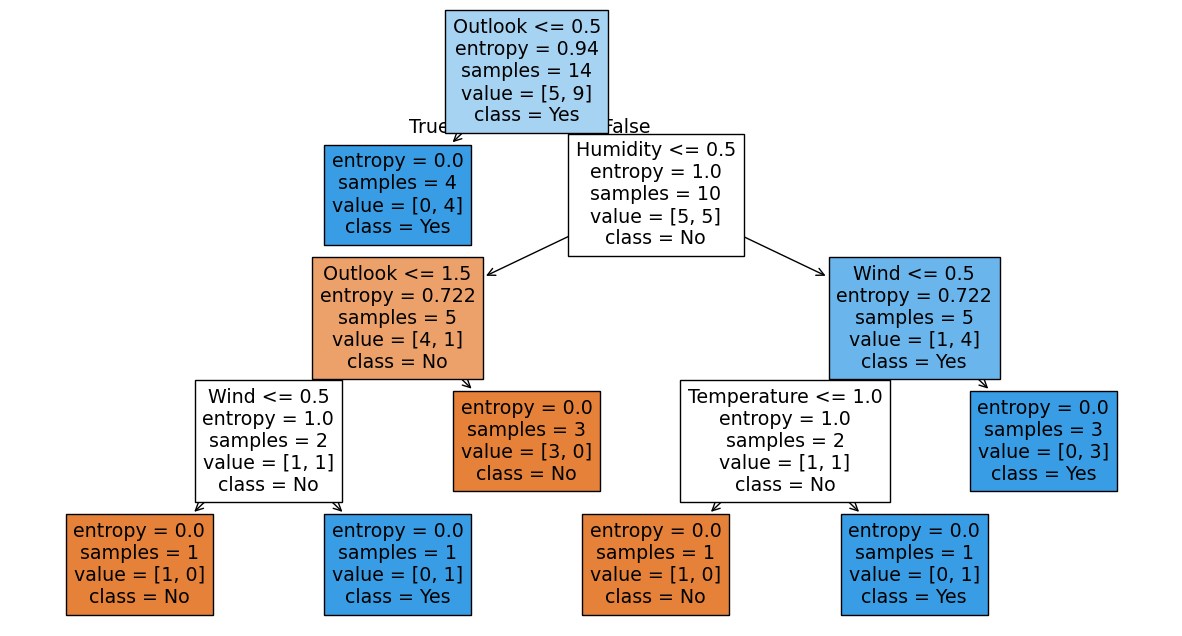


Predicted Class: No


In [4]:
# Q3 - ID3 Decision Tree

import pandas as pd
import math

# Dataset
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain',
                'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain',
                'Sunny', 'Overcast', 'Overcast', 'Rain'],

    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool',
                    'Cool', 'Cool', 'Mild', 'Cool', 'Mild',
                    'Mild', 'Mild', 'Hot', 'Mild'],

    'Humidity': ['High', 'High', 'High', 'High', 'Normal',
                 'Normal', 'Normal', 'High', 'Normal', 'Normal',
                 'Normal', 'High', 'Normal', 'High'],

    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak',
             'Strong', 'Strong', 'Weak', 'Weak', 'Weak',
             'Strong', 'Strong', 'Weak', 'Strong'],

    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes',
             'No', 'Yes', 'No', 'Yes', 'Yes',
             'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)

# Entropy
def entropy(data):

    values = data.value_counts()
    total = len(data)

    result = 0

    for count in values:
        p = count / total
        result -= p * math.log2(p)

    return result


# Information Gain
def information_gain(df, attribute, target):

    total_entropy = entropy(df[target])

    weighted_entropy = 0

    for value in df[attribute].unique():

        subset = df[df[attribute] == value]

        weighted_entropy += (
            len(subset) / len(df)
        ) * entropy(subset[target])

    return total_entropy - weighted_entropy


print("Information Gain:")

for attribute in df.columns[:-1]:
    gain = information_gain(df, attribute, 'Play')
    print(attribute, ":", round(gain, 4))


# Build decision tree using sklearn
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

encoded_df = df.copy()

encoders = {}

for column in encoded_df.columns:

    encoder = LabelEncoder()
    encoded_df[column] = encoder.fit_transform(encoded_df[column])
    encoders[column] = encoder

X = encoded_df.drop('Play', axis=1)
y = encoded_df['Play']

model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

model.fit(X, y)

plt.figure(figsize=(15, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=encoders['Play'].classes_,
    filled=True
)

plt.show()


# Classify a new sample
new_sample = pd.DataFrame({
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
})

for column in new_sample.columns:
    new_sample[column] = encoders[column].transform(new_sample[column])

prediction = model.predict(new_sample)

print("\nPredicted Class:",
      encoders['Play'].inverse_transform(prediction)[0])

In [5]:
# Q4 - ANN using Backpropagation

import numpy as np

np.random.seed(42)

# XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# Network parameters
input_neurons = 2
hidden_neurons = 4
output_neurons = 1

learning_rate = 0.5
epochs = 10000


# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return x * (1 - x)


# Initialize weights
W1 = np.random.randn(input_neurons, hidden_neurons)
b1 = np.zeros((1, hidden_neurons))

W2 = np.random.randn(hidden_neurons, output_neurons)
b2 = np.zeros((1, output_neurons))


# Training
for epoch in range(epochs):

    # Forward propagation
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    output_input = np.dot(hidden_output, W2) + b2
    output = sigmoid(output_input)

    # Error
    error = y - output

    # Backpropagation
    d_output = error * sigmoid_derivative(output)

    error_hidden = d_output.dot(W2.T)

    d_hidden = error_hidden * sigmoid_derivative(hidden_output)

    # Update weights
    W2 += hidden_output.T.dot(d_output) * learning_rate
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate

    W1 += X.T.dot(d_hidden) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate


# Testing
print("Predictions:")

predictions = output > 0.5

for i in range(len(X)):
    print(
        X[i],
        "Actual:",
        y[i][0],
        "Predicted:",
        int(predictions[i][0])
    )

Predictions:
[0 0] Actual: 0 Predicted: 0
[0 1] Actual: 1 Predicted: 1
[1 0] Actual: 1 Predicted: 1
[1 1] Actual: 0 Predicted: 0


In [6]:
# Q5 - KNN from First Principles

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Iris dataset
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Euclidean distance
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


# KNN
def knn_predict(X_train, y_train, X_test, k):

    predictions = []

    for test_point in X_test:

        distances = []

        for i in range(len(X_train)):

            distance = euclidean_distance(
                test_point,
                X_train[i]
            )

            distances.append(
                (distance, y_train[i])
            )

        distances.sort(key=lambda x: x[0])

        nearest_neighbors = distances[:k]

        labels = [
            label for distance, label
            in nearest_neighbors
        ]

        values, counts = np.unique(
            labels,
            return_counts=True
        )

        prediction = values[np.argmax(counts)]

        predictions.append(prediction)

    return np.array(predictions)


# Test different K values
for k in [1, 3, 5, 7, 9]:

    prediction = knn_predict(
        X_train,
        y_train,
        X_test,
        k
    )

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    print(
        "K =", k,
        "Accuracy =", round(accuracy, 4)
    )

K = 1 Accuracy = 0.9667
K = 3 Accuracy = 0.9333
K = 5 Accuracy = 0.9333
K = 7 Accuracy = 0.9667
K = 9 Accuracy = 0.9667


Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


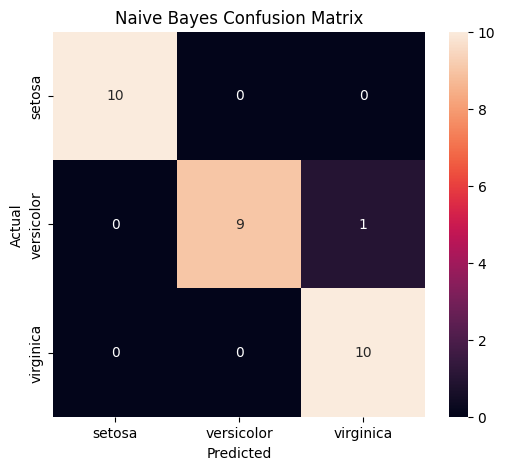

In [7]:
# Q6 - Naive Bayes

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Naive Bayes
model = GaussianNB()

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Visualization
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [8]:
# Q7 - Logistic Regression

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Logistic Regression Accuracy:",
      accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Logistic Regression Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Mean Absolute Error: 52.259976445345536
Root Mean Squared Error: 63.73245584860925
R2 Score: 0.23335039815872138


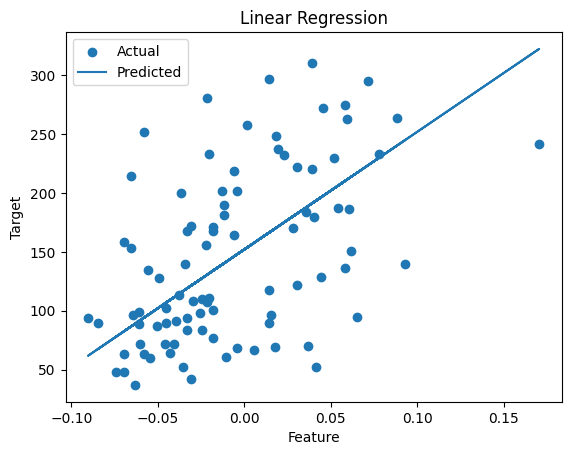

In [9]:
# Q8 - Linear Regression

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
data = load_diabetes()

# Use one feature
X = data.data[:, [2]]
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Linear Regression
model = LinearRegression()

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# Visualization
plt.scatter(
    X_test,
    y_test,
    label="Actual"
)

plt.plot(
    X_test,
    y_pred,
    label="Predicted"
)

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression")
plt.legend()

plt.show()

Linear Regression
RMSE: 7.266360849833978
R2: 0.9497645211930926

Polynomial Regression
RMSE: 4.8910333213777214e-15
R2: 1.0


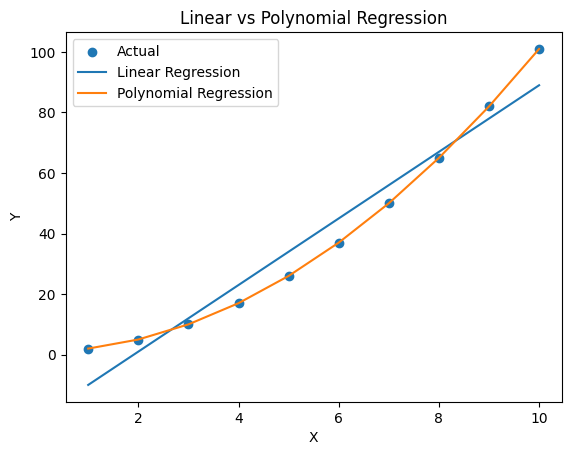

In [10]:
# Q9 - Linear vs Polynomial Regression

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
X = np.array([
    [1], [2], [3], [4], [5],
    [6], [7], [8], [9], [10]
])

y = np.array([
    2, 5, 10, 17, 26,
    37, 50, 65, 82, 101
])

# Linear Regression
linear_model = LinearRegression()

linear_model.fit(X, y)

linear_pred = linear_model.predict(X)

# Polynomial Regression
poly = PolynomialFeatures(
    degree=2
)

X_poly = poly.fit_transform(X)

poly_model = LinearRegression()

poly_model.fit(X_poly, y)

poly_pred = poly_model.predict(X_poly)

# Evaluation
linear_rmse = np.sqrt(
    mean_squared_error(y, linear_pred)
)

poly_rmse = np.sqrt(
    mean_squared_error(y, poly_pred)
)

linear_r2 = r2_score(y, linear_pred)

poly_r2 = r2_score(y, poly_pred)

print("Linear Regression")
print("RMSE:", linear_rmse)
print("R2:", linear_r2)

print("\nPolynomial Regression")
print("RMSE:", poly_rmse)
print("R2:", poly_r2)

# Visualization
plt.scatter(
    X,
    y,
    label="Actual"
)

plt.plot(
    X,
    linear_pred,
    label="Linear Regression"
)

plt.plot(
    X,
    poly_pred,
    label="Polynomial Regression"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear vs Polynomial Regression")
plt.legend()

plt.show()

Final Means:
[[1.90754861 2.02721789]
 [7.102599   7.03479012]]

Final Variances:
[[0.46460138 0.63215449]
 [0.68475252 0.55365964]]

Mixing Probabilities:
[0.5 0.5]


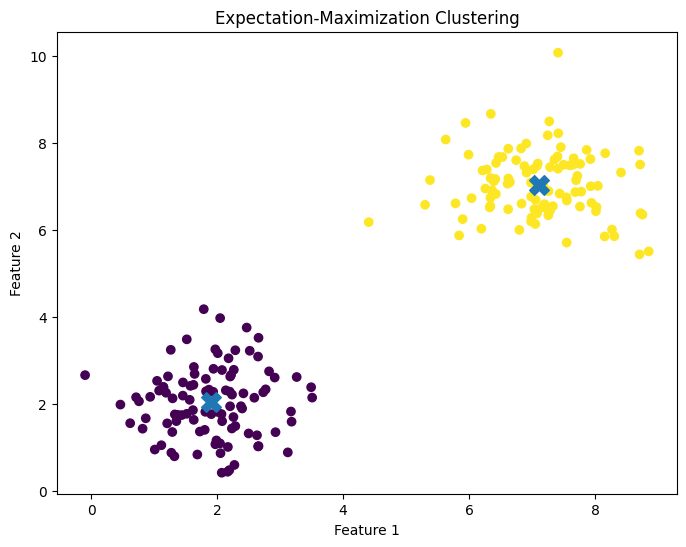

In [11]:
# Q10 - Expectation Maximization Algorithm

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate sample data
X1 = np.random.normal(
    loc=[2, 2],
    scale=0.8,
    size=(100, 2)
)

X2 = np.random.normal(
    loc=[7, 7],
    scale=0.8,
    size=(100, 2)
)

X = np.vstack((X1, X2))

# Number of clusters
K = 2

n = len(X)

# Initial means
means = np.array([
    X[np.random.randint(n)],
    X[np.random.randint(n)]
])

# Initial variances
variances = np.array([
    np.ones(2),
    np.ones(2)
])

# Initial mixing probabilities
pi = np.ones(K) / K


# Gaussian probability
def gaussian_probability(x, mean, variance):

    return (
        1 / np.sqrt(
            2 * np.pi * variance
        )
        *
        np.exp(
            -(x - mean) ** 2
            / (2 * variance)
        )
    ).prod()


# EM iterations
for iteration in range(50):

    # -------------------
    # E-STEP
    # -------------------

    responsibilities = np.zeros(
        (n, K)
    )

    for i in range(n):

        probabilities = []

        for k in range(K):

            probability = (
                pi[k]
                *
                gaussian_probability(
                    X[i],
                    means[k],
                    variances[k]
                )
            )

            probabilities.append(
                probability
            )

        total = sum(probabilities)

        if total == 0:
            responsibilities[i] = 1 / K
        else:
            responsibilities[i] = (
                np.array(probabilities) / total
            )


    # -------------------
    # M-STEP
    # -------------------

    for k in range(K):

        Nk = np.sum(
            responsibilities[:, k]
        )

        # Update mean
        means[k] = (
            np.sum(
                responsibilities[:, k][:, None]
                * X,
                axis=0
            ) / Nk
        )

        # Update variance
        variances[k] = (
            np.sum(
                responsibilities[:, k][:, None]
                *
                (X - means[k]) ** 2,
                axis=0
            ) / Nk
        )

        # Update mixing probability
        pi[k] = Nk / n


print("Final Means:")
print(means)

print("\nFinal Variances:")
print(variances)

print("\nMixing Probabilities:")
print(pi)


# Assign clusters
clusters = np.argmax(
    responsibilities,
    axis=1
)

# Visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=clusters
)

plt.scatter(
    means[:, 0],
    means[:, 1],
    marker='X',
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Expectation-Maximization Clustering")

plt.show()